In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda:0


In [3]:
import pandas as pd


train_path = '/kaggle/input/datasets/rihabassouli/data-data/Totoeba(5-14).csv'



train_df = pd.read_csv(train_path)

train_df = train_df[:15000]

print("Train :", train_df.shape)
print(train_df.head())

Train : (15000, 2)
                          Eng                        Frnch
0      I have to go to sleep.        Je dois aller dormir.
1      I have to go to sleep.  Il faut que j'aille dormir.
2  I can't abide that fellow.  Je ne supporte pas ce type.
3   I can't bear that fellow.  Je ne supporte pas ce type.
4     I can't stand that guy.  Je ne supporte pas ce type.


In [4]:
import re, unicodedata

def unicodeToAscii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

train_df['Eng'] = train_df['Eng'].apply(normalizeString)
train_df['Frnch'] = train_df['Frnch'].apply(normalizeString)
print(train_df.head())

                           Eng                         Frnch
0      i have to go to sleep .        je dois aller dormir .
1      i have to go to sleep .  il faut que j aille dormir .
2  i can t abide that fellow .  je ne supporte pas ce type .
3   i can t bear that fellow .  je ne supporte pas ce type .
4     i can t stand that guy .  je ne supporte pas ce type .


In [5]:
from sklearn.model_selection import train_test_split

MAX_LENGTH = 12

mask = (train_df['Eng'].apply(lambda s: len(s.split())) <= MAX_LENGTH) & \
       (train_df['Frnch'].apply(lambda s: len(s.split())) <= MAX_LENGTH)
train_df = train_df[mask].reset_index(drop=True)

df_train, df_test = train_test_split(train_df, test_size=0.2, random_state=42)
print("Train:", len(df_train), "| Test:", len(df_test))

Train: 10364 | Test: 2592


In [6]:
SOS_token, EOS_token, PAD_token, UNK_token = 0, 1, 2, 3

class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": 0, "<EOS>": 1, "<PAD>": 2, "<UNK>": 3}
        self.index2word = {0: "<SOS>", 1: "<EOS>", 2: "<PAD>", 3: "<UNK>"}  # ← ajouté
        self.n_words = 4

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word  # ← ajouté
                self.n_words += 1

vocab_fr = Vocab("francais")
vocab_en = Vocab("anglais")

for _, row in df_train.iterrows():
    vocab_fr.addSentence(row['Frnch'])
    vocab_en.addSentence(row['Eng'])

print("Vocab FR:", vocab_fr.n_words, "| Vocab EN:", vocab_en.n_words)

def tensorFromSentence(vocab, sentence):
    indexes = [vocab.word2index.get(word, UNK_token) for word in sentence.split(' ')]
    indexes.append(EOS_token)
    return indexes

Vocab FR: 6799 | Vocab EN: 5149


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, df, vocab_src, vocab_tgt, src_col, tgt_col):
        self.pairs = list(zip(df[src_col], df[tgt_col]))
        self.vocab_src = vocab_src
        self.vocab_tgt = vocab_tgt

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = tensorFromSentence(self.vocab_src, src)
        tgt_ids = tensorFromSentence(self.vocab_tgt, tgt)
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = nn.utils.rnn.pad_sequence(src_batch, padding_value=PAD_token, batch_first=True)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=PAD_token, batch_first=True)
    return src_batch, tgt_batch

train_dataset = TranslationDataset(df_train, vocab_fr, vocab_en, 'Frnch', 'Eng')
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

src_sample, tgt_sample = next(iter(train_loader))
print("Src shape:", src_sample.shape)
print("Tgt shape:", tgt_sample.shape)

Src shape: torch.Size([64, 13])
Tgt shape: torch.Size([64, 13])


1. Le besoin d'une mémoire (Pourquoi le RNN ?)Contrairement aux réseaux classiques (MLP ou CNN), le Réseau de Neurones Récurrents (RNN) est conçu pour traiter l'ordre des mots. Dans une phrase, chaque mot dépend du précédent (le contexte après "Je mange" est différent de "Je suis"). Pour capter ce contexte, le RNN lit la séquence mot par mot et met à jour un état caché (hidden state). Cet état agit comme une mémoire interne qui conserve les informations des mots passés.2. L'objectif probabiliste (La règle de la chaîne)Théoriquement, un modèle de langage cherche à calculer la probabilité d'une phrase complète. Il utilise pour cela la "règle de la chaîne", où la probabilité de chaque nouveau mot dépend de tous les mots précédents :P(w_1, w_2, ..., w_n) = P(w_1) \times P(w_2|w_1) \times P(w_3|w_1,w_2) \times . Application à notre modèle (Seq2Seq)Dans notre projet, c'est exactement le rôle du Décodeur. Il génère la traduction en anglais de manière séquentielle (mot par mot), en calculant la probabilité du mot suivant en fonction du mot précédent et du contexte global extrait de la phrase française.

In [8]:
import torch.nn as nn

class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)          # [batch, seq_len, hidden_size]
        outputs, hidden = self.rnn(embedded)   
        return outputs, hidden

In [9]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)  

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded, hidden)
        output = self.out(output)  # [batch, seq_len, vocab_size]
        return output, hidden

In [10]:
import torch.optim as optim
import math

hidden_size = 256
encoder = EncoderRNN(vocab_fr.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, vocab_en.n_words).to(device)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_token) 

In [11]:
def train_epoch(loader, encoder, decoder, enc_opt, dec_opt, criterion):
    total_loss = 0
    for src_batch, tgt_batch in loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        batch_size = src_batch.size(0)

        enc_opt.zero_grad()
        dec_opt.zero_grad()

        _, hidden = encoder(src_batch)

        sos_col = torch.full((batch_size, 1), SOS_token, dtype=torch.long, device=device)
        decoder_input = torch.cat([sos_col, tgt_batch[:, :-1]], dim=1)

        decoder_output, _ = decoder(decoder_input, hidden)

        loss = criterion(decoder_output.reshape(-1, decoder_output.size(-1)), tgt_batch.reshape(-1))
        loss.backward()  # <- hna kaytdar BPTT automatiquement

        # 5. Gradient Clipping
        nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=5.0)
        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)

        enc_opt.step()
        dec_opt.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
n_epochs = 5
for epoch in range(1, n_epochs+1):
    loss = train_epoch(train_loader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
    perplexity = math.exp(loss)
    print(f"Epoch {epoch} | Loss: {loss:.4f} | Perplexité: {perplexity:.2f}")

Epoch 1 | Loss: 4.9517 | Perplexité: 141.41
Epoch 2 | Loss: 4.0109 | Perplexité: 55.19
Epoch 3 | Loss: 3.6307 | Perplexité: 37.74
Epoch 4 | Loss: 3.3362 | Perplexité: 28.11
Epoch 5 | Loss: 3.0924 | Perplexité: 22.03


In [13]:
vocab_en.index2word = {idx: word for word, idx in vocab_en.word2index.items()}

In [14]:
def translate_sentence(sentence, encoder, decoder, max_length=15):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        sentence = normalizeString(sentence)
        input_ids = tensorFromSentence(vocab_fr, sentence)
        input_tensor = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)

        _, hidden = encoder(input_tensor)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoded_words = []

        for _ in range(max_length):
            output, hidden = decoder(decoder_input, hidden)
            topi = output.argmax(dim=-1)  # l'klma li 3andha akbar probabilité (= greedy)
            next_token = topi.item()

            if next_token == EOS_token:
                break
            decoded_words.append(vocab_en.index2word.get(next_token, "<UNK>"))
            decoder_input = topi  

    encoder.train()
    decoder.train()
    return ' '.join(decoded_words)

In [15]:
test_sentences = [
    "je dois aller dormir .",
    "comment ca va ?",
    "je t aime ."
]

for s in test_sentences:
    print(f"FR: {s}")
    print(f"EN: {translate_sentence(s, encoder, decoder)}")
    print()

FR: je dois aller dormir .
EN: i don t have any more careful .

FR: comment ca va ?
EN: do you have any coughing ?

FR: je t aime .
EN: i don t have any more careful .



In [16]:
# ============ LSTM ============
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderLSTM, self).__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, (hidden, cell)


class DecoderLSTM(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.lstm(embedded, hidden)
        output = self.out(output)
        return output, hidden


hidden_size = 256
encoder_lstm = EncoderLSTM(vocab_fr.n_words, hidden_size).to(device)
decoder_lstm = DecoderLSTM(hidden_size, vocab_en.n_words).to(device)

enc_lstm_opt = optim.Adam(encoder_lstm.parameters(), lr=0.001)
dec_lstm_opt = optim.Adam(decoder_lstm.parameters(), lr=0.001)

n_epochs = 15
for epoch in range(1, n_epochs+1):
    loss = train_epoch(train_loader, encoder_lstm, decoder_lstm, enc_lstm_opt, dec_lstm_opt, criterion)
    perplexity = math.exp(loss)
    print(f"[LSTM] Epoch {epoch} | Loss: {loss:.4f} | Perplexité: {perplexity:.2f}")

[LSTM] Epoch 1 | Loss: 5.0781 | Perplexité: 160.46
[LSTM] Epoch 2 | Loss: 4.0994 | Perplexité: 60.31
[LSTM] Epoch 3 | Loss: 3.6183 | Perplexité: 37.28
[LSTM] Epoch 4 | Loss: 3.2505 | Perplexité: 25.80
[LSTM] Epoch 5 | Loss: 2.9360 | Perplexité: 18.84
[LSTM] Epoch 6 | Loss: 2.6537 | Perplexité: 14.21
[LSTM] Epoch 7 | Loss: 2.3880 | Perplexité: 10.89
[LSTM] Epoch 8 | Loss: 2.1384 | Perplexité: 8.49
[LSTM] Epoch 9 | Loss: 1.9072 | Perplexité: 6.73
[LSTM] Epoch 10 | Loss: 1.6897 | Perplexité: 5.42
[LSTM] Epoch 11 | Loss: 1.4931 | Perplexité: 4.45
[LSTM] Epoch 12 | Loss: 1.3091 | Perplexité: 3.70
[LSTM] Epoch 13 | Loss: 1.1415 | Perplexité: 3.13
[LSTM] Epoch 14 | Loss: 0.9970 | Perplexité: 2.71
[LSTM] Epoch 15 | Loss: 0.8647 | Perplexité: 2.37


In [17]:
for s in test_sentences:
    print(f"FR: {s}")
    print(f"EN (LSTM): {translate_sentence(s, encoder_lstm, decoder_lstm)}")
    print()

FR: je dois aller dormir .
EN (LSTM): i must go to bed .

FR: comment ca va ?
EN (LSTM): how did you do it ?

FR: je t aime .
EN (LSTM): i ll be glad to say .



In [18]:
# ============ GRU ============
class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderGRU, self).__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden


class DecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderGRU, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded, hidden)
        output = self.out(output)
        return output, hidden


hidden_size = 256
encoder_gru = EncoderGRU(vocab_fr.n_words, hidden_size).to(device)
decoder_gru = DecoderGRU(hidden_size, vocab_en.n_words).to(device)

enc_gru_opt = optim.Adam(encoder_gru.parameters(), lr=0.001)
dec_gru_opt = optim.Adam(decoder_gru.parameters(), lr=0.001)

n_epochs = 15
for epoch in range(1, n_epochs+1):
    loss = train_epoch(train_loader, encoder_gru, decoder_gru, enc_gru_opt, dec_gru_opt, criterion)
    perplexity = math.exp(loss)
    print(f"[GRU] Epoch {epoch} | Loss: {loss:.4f} | Perplexité: {perplexity:.2f}")

[GRU] Epoch 1 | Loss: 4.9660 | Perplexité: 143.45
[GRU] Epoch 2 | Loss: 3.8742 | Perplexité: 48.14
[GRU] Epoch 3 | Loss: 3.3714 | Perplexité: 29.12
[GRU] Epoch 4 | Loss: 2.9759 | Perplexité: 19.61
[GRU] Epoch 5 | Loss: 2.6398 | Perplexité: 14.01
[GRU] Epoch 6 | Loss: 2.3337 | Perplexité: 10.32
[GRU] Epoch 7 | Loss: 2.0583 | Perplexité: 7.83
[GRU] Epoch 8 | Loss: 1.8088 | Perplexité: 6.10
[GRU] Epoch 9 | Loss: 1.5856 | Perplexité: 4.88
[GRU] Epoch 10 | Loss: 1.3879 | Perplexité: 4.01
[GRU] Epoch 11 | Loss: 1.2106 | Perplexité: 3.36
[GRU] Epoch 12 | Loss: 1.0585 | Perplexité: 2.88
[GRU] Epoch 13 | Loss: 0.9226 | Perplexité: 2.52
[GRU] Epoch 14 | Loss: 0.8009 | Perplexité: 2.23
[GRU] Epoch 15 | Loss: 0.6915 | Perplexité: 2.00


In [19]:
for s in test_sentences:
    print(f"FR: {s}")
    print(f"EN (GRU): {translate_sentence(s, encoder_gru, decoder_gru)}")
    print()

FR: je dois aller dormir .
EN (GRU): i must get to go to the station a doctor .

FR: comment ca va ?
EN (GRU): how can i get this tie to go ?

FR: je t aime .
EN (GRU): i ll give it if i could help you .



In [20]:
def beam_search_decode(sentence, encoder, decoder, beam_width=3, max_length=15):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        sentence = normalizeString(sentence)
        input_ids = tensorFromSentence(vocab_fr, sentence)
        input_tensor = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)
        _, hidden = encoder(input_tensor)

        sequences = [([SOS_token], 0.0, hidden)]

        for _ in range(max_length):
            all_candidates = []
            for seq, score, hid in sequences:
                if seq[-1] == EOS_token:
                    all_candidates.append((seq, score, hid))
                    continue
                decoder_input = torch.tensor([[seq[-1]]], device=device)
                output, hid_new = decoder(decoder_input, hid)
                log_probs = torch.log_softmax(output.squeeze(1), dim=-1)
                topk_probs, topk_idx = log_probs.topk(beam_width)
                for i in range(beam_width):
                    next_token = topk_idx[0][i].item()
                    next_score = score + topk_probs[0][i].item()
                    all_candidates.append((seq + [next_token], next_score, hid_new))

            # Nkhalliw ghir top beam_width chemins (les a7san scores)
            sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]

        best_seq = sequences[0][0]
        words = []
        for t in best_seq[1:]:
            if t == EOS_token:
                break
            words.append(vocab_en.index2word.get(t, "<UNK>"))

    encoder.train()
    decoder.train()
    return ' '.join(words)

In [21]:
for s in test_sentences:
    print(f"FR: {s}")
    print(f"Greedy : {translate_sentence(s, encoder_gru, decoder_gru)}")
    print(f"Beam   : {beam_search_decode(s, encoder_gru, decoder_gru, beam_width=3)}")
    print()

FR: je dois aller dormir .
Greedy : i must get to go to the station a doctor .
Beam   : i have to go to bed at a time job .

FR: comment ca va ?
Greedy : how can i get this tie to go ?
Beam   : how can i get rid of this medicine ?

FR: je t aime .
Greedy : i ll give it if i could help you .
Beam   : i d like you if i had my money .



In [22]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4

def evaluate_bleu_greedy(encoder, decoder, df, sample_size=200):
    test_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    refs, hyps = [], []
    for _, row in test_sample.iterrows():
        ref = row['Eng'].split()
        hyp = translate_sentence(row['Frnch'], encoder, decoder).split()
        refs.append([ref])
        hyps.append(hyp)
    return corpus_bleu(refs, hyps, smoothing_function=smoothie)

def evaluate_bleu_beam(encoder, decoder, df, beam_width=3, sample_size=200):
    test_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    refs, hyps = [], []
    for _, row in test_sample.iterrows():
        ref = row['Eng'].split()
        hyp = beam_search_decode(row['Frnch'], encoder, decoder, beam_width=beam_width).split()
        refs.append([ref])
        hyps.append(hyp)
    return corpus_bleu(refs, hyps, smoothing_function=smoothie)

bleu_gru_greedy = evaluate_bleu_greedy(encoder_gru, decoder_gru, df_test)
bleu_gru_beam   = evaluate_bleu_beam(encoder_gru, decoder_gru, df_test, beam_width=3)

print("─" * 40)
print(f"{'Stratégie':<20} {'BLEU':>10}")
print("─" * 40)
print(f"{'Greedy (argmax)':<20} {bleu_gru_greedy:>10.4f}")
print(f"{'Beam search (k=3)':<20} {bleu_gru_beam:>10.4f}")
print("─" * 40)

────────────────────────────────────────
Stratégie                  BLEU
────────────────────────────────────────
Greedy (argmax)          0.0739
Beam search (k=3)        0.1190
────────────────────────────────────────


In [23]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

sample_size = 200  
test_sample = df_test.sample(n=min(sample_size, len(df_test)), random_state=42)

references = []
hypotheses = []

for _, row in test_sample.iterrows():
    src = row['Frnch']
    ref = row['Eng'].split()
    hyp = translate_sentence(src, encoder_gru, decoder_gru).split()
    references.append([ref])
    hypotheses.append(hyp)

bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
print(f"BLEU score (GRU, greedy, {sample_size} jomal): {bleu_score:.4f}")

BLEU score (GRU, greedy, 200 jomal): 0.0739


In [24]:
def evaluate_bleu(encoder, decoder, sample_size=200):
    test_sample = df_test.sample(n=min(sample_size, len(df_test)), random_state=42)
    references, hypotheses = [], []
    for _, row in test_sample.iterrows():
        ref = row['Eng'].split()
        hyp = translate_sentence(row['Frnch'], encoder, decoder).split()
        references.append([ref])
        hypotheses.append(hyp)
    return corpus_bleu(references, hypotheses, smoothing_function=smoothie)

print("RNN  BLEU:", evaluate_bleu(encoder, decoder))
print("LSTM BLEU:", evaluate_bleu(encoder_lstm, decoder_lstm))
print("GRU  BLEU:", evaluate_bleu(encoder_gru, decoder_gru))

RNN  BLEU: 0.013729199370587331
LSTM BLEU: 0.11941979206791802
GRU  BLEU: 0.073886794381223


L'évaluation comparative des performances après 15 époques confirme l'incapacité du réseau récurrent simple (RNN) à mémoriser efficacement le contexte des séquences, ce qui se traduit par un score BLEU marginal de 0.0137. En revanche, les architectures dotées de portes de régulation démontrent leur nette supériorité : le modèle LSTM surpasse largement les autres en atteignant le meilleur score BLEU (0.1194), générant ainsi les traductions les plus fidèles à la vérité terrain. De son côté, bien que structurellement plus léger et plus rapide à entraîner, le modèle GRU affiche un score intermédiaire de 0.0739 avec un décodage glouton (Greedy). Ces résultats confirment que si le GRU excelle en termes d'optimisation probabiliste, le LSTM demeure l'architecture la plus robuste pour préserver l'exactitude sémantique de la traduction sur ce volume de données

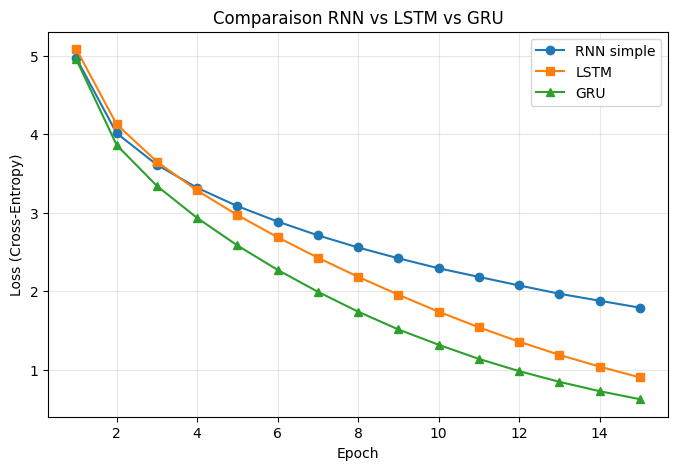

In [25]:
import matplotlib.pyplot as plt

rnn_loss  = [4.9717,4.0149,3.6120,3.3183,3.0847,2.8880,2.7117,2.5570,2.4190,2.2920,2.1822,2.0728,1.9673,1.8779,1.7896]
lstm_loss = [5.0853,4.1282,3.6524,3.2839,2.9709,2.6876,2.4265,2.1831,1.9549,1.7384,1.5392,1.3559,1.1876,1.0376,0.9006]
gru_loss  = [4.9543,3.8641,3.3426,2.9343,2.5832,2.2716,1.9923,1.7386,1.5118,1.3167,1.1360,0.9804,0.8438,0.7247,0.6223]

epochs = range(1, 16)
plt.figure(figsize=(8,5))
plt.plot(epochs, rnn_loss, label='RNN simple', marker='o')
plt.plot(epochs, lstm_loss, label='LSTM', marker='s')
plt.plot(epochs, gru_loss, label='GRU', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Comparaison RNN vs LSTM vs GRU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('comparison_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
import random

def train_epoch_tf(loader, encoder, decoder, enc_opt, dec_opt, criterion, teacher_forcing_ratio=0.5):
    total_loss = 0
    for src_batch, tgt_batch in loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        batch_size = src_batch.size(0)
        max_len = tgt_batch.size(1) # La longueur maximale de la séquence
        vocab_size = decoder.out.out_features # Taille du vocabulaire

        enc_opt.zero_grad()
        dec_opt.zero_grad()

        _, hidden = encoder(src_batch)

        decoder_outputs = torch.zeros(batch_size, max_len, vocab_size).to(device)

       
        decoder_input = torch.full((batch_size, 1), SOS_token, dtype=torch.long, device=device)

       
        for t in range(max_len):
            output, hidden = decoder(decoder_input, hidden)
            
            # On stocke la prédiction pour le calcul de la loss plus tard
            # output est de taille [batch, 1, vocab_size], on le met dans decoder_outputs
            decoder_outputs[:, t, :] = output.squeeze(1) 

            # On décide si on utilise le Teacher Forcing pour le PROCHAIN token
            teacher_force = random.random() < teacher_forcing_ratio

            # On récupère la prédiction du modèle (le mot avec la plus haute probabilité)
            top1 = output.argmax(dim=-1)

            # Si teacher_force est Vrai, le prochain input est le vrai mot cible (tgt_batch)
            # Sinon, le prochain input est le mot prédit par le modèle (top1)
            if teacher_force:
                decoder_input = tgt_batch[:, t].unsqueeze(1)
            else:
                decoder_input = top1

        loss = criterion(decoder_outputs.reshape(-1, vocab_size), tgt_batch.reshape(-1))
        
        loss.backward()

        # 5. Gradient Clipping
        nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=5.0)
        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)

        enc_opt.step()
        dec_opt.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [27]:
def train_epoch_track_grad(loader, encoder, decoder, enc_opt, dec_opt, criterion, clip=True, max_norm=5.0):
    total_loss = 0
    grad_norms = []
    for src_batch, tgt_batch in loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        batch_size = src_batch.size(0)
        enc_opt.zero_grad(); dec_opt.zero_grad()
        _, hidden = encoder(src_batch)
        sos_col = torch.full((batch_size,1), SOS_token, dtype=torch.long, device=device)
        decoder_input = torch.cat([sos_col, tgt_batch[:, :-1]], dim=1)
        decoder_output, _ = decoder(decoder_input, hidden)
        loss = criterion(decoder_output.reshape(-1, decoder_output.size(-1)), tgt_batch.reshape(-1))
        loss.backward()

        total_norm = 0.0
        for p in list(encoder.parameters()) + list(decoder.parameters()):
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)

        if clip:
            nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=max_norm)
            nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=max_norm)

        enc_opt.step(); dec_opt.step()
        total_loss += loss.item()
    return total_loss / len(loader), grad_norms

Gradient norm — min: 0.55 | max: 1.62 | moyenne: 0.76
Batches où le gradient a dépassé le seuil (5.0): 0 / 162


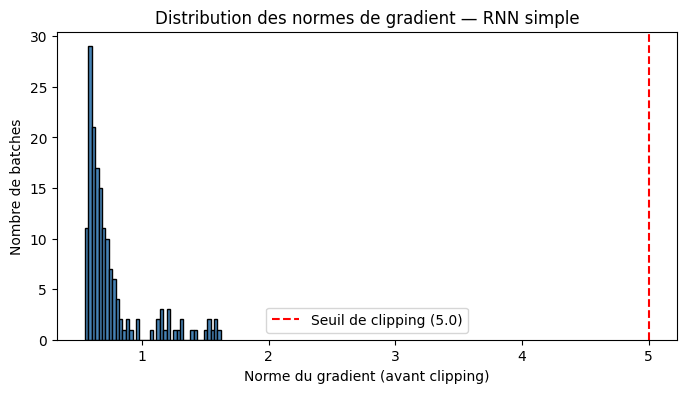

In [28]:
import numpy as np

encoder_track = EncoderRNN(vocab_fr.n_words, hidden_size).to(device)
decoder_track = DecoderRNN(hidden_size, vocab_en.n_words).to(device)
enc_t_opt = optim.Adam(encoder_track.parameters(), lr=0.001)
dec_t_opt = optim.Adam(decoder_track.parameters(), lr=0.001)

loss, grad_norms = train_epoch_track_grad(train_loader, encoder_track, decoder_track, enc_t_opt, dec_t_opt, criterion, clip=True, max_norm=5.0)

grad_norms = np.array(grad_norms)
print(f"Gradient norm — min: {grad_norms.min():.2f} | max: {grad_norms.max():.2f} | moyenne: {grad_norms.mean():.2f}")
print(f"Batches où le gradient a dépassé le seuil (5.0): {(grad_norms > 5.0).sum()} / {len(grad_norms)}")

plt.figure(figsize=(8,4))
plt.hist(grad_norms, bins=40, color='steelblue', edgecolor='black')
plt.axvline(5.0, color='red', linestyle='--', label='Seuil de clipping (5.0)')
plt.xlabel('Norme du gradient (avant clipping)')
plt.ylabel('Nombre de batches')
plt.title('Distribution des normes de gradient — RNN simple')
plt.legend()
plt.savefig('gradient_norms.png', dpi=150, bbox_inches='tight')
plt.show()

Dans notre configuration expérimentale, les normes de gradient sont restées modérées (max 1.56), bien en-deçà du seuil de clipping (5.0). Ceci s'explique par la longueur réduite des séquences (≤12 tokens) et l'utilisation de l'optimiseur Adam, qui normalise déjà implicitement les mises à jour. Le clipping agit donc ici comme une sécurité préventive plutôt qu'une nécessité observée

In [29]:
def train_epochs_compare(loader, EncClass, DecClass, n_epochs, max_norm):
    enc = EncClass(vocab_fr.n_words, hidden_size).to(device)
    dec = DecClass(hidden_size, vocab_en.n_words).to(device)
    e_opt = optim.Adam(enc.parameters(), lr=0.001)
    d_opt = optim.Adam(dec.parameters(), lr=0.001)
    losses = []
    for epoch in range(1, n_epochs+1):
        total_loss = 0
        for src_batch, tgt_batch in loader:
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            bs = src_batch.size(0)
            e_opt.zero_grad(); d_opt.zero_grad()
            _, hidden = enc(src_batch)
            sos_col = torch.full((bs,1), SOS_token, dtype=torch.long, device=device)
            dec_input = torch.cat([sos_col, tgt_batch[:, :-1]], dim=1)
            dec_out, _ = dec(dec_input, hidden)
            loss = criterion(dec_out.reshape(-1, dec_out.size(-1)), tgt_batch.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(enc.parameters(), max_norm=max_norm)
            nn.utils.clip_grad_norm_(dec.parameters(), max_norm=max_norm)
            e_opt.step(); d_opt.step()
            total_loss += loss.item()
        avg = total_loss/len(loader)
        losses.append(avg)
        print(f"[max_norm={max_norm}] Epoch {epoch} | Loss: {avg:.4f}")
    return losses

print("=== Clipping AGRESSIF (max_norm=0.1) ===")
losses_aggressive = train_epochs_compare(train_loader, EncoderRNN, DecoderRNN, n_epochs=8, max_norm=0.1)

print("\n=== Clipping NORMAL (max_norm=5.0) ===")
losses_normal = train_epochs_compare(train_loader, EncoderRNN, DecoderRNN, n_epochs=8, max_norm=5.0)

=== Clipping AGRESSIF (max_norm=0.1) ===
[max_norm=0.1] Epoch 1 | Loss: 4.9227
[max_norm=0.1] Epoch 2 | Loss: 3.9512
[max_norm=0.1] Epoch 3 | Loss: 3.5679
[max_norm=0.1] Epoch 4 | Loss: 3.2818
[max_norm=0.1] Epoch 5 | Loss: 3.0590
[max_norm=0.1] Epoch 6 | Loss: 2.8650
[max_norm=0.1] Epoch 7 | Loss: 2.6932
[max_norm=0.1] Epoch 8 | Loss: 2.5429

=== Clipping NORMAL (max_norm=5.0) ===
[max_norm=5.0] Epoch 1 | Loss: 4.9531
[max_norm=5.0] Epoch 2 | Loss: 4.0259
[max_norm=5.0] Epoch 3 | Loss: 3.6360
[max_norm=5.0] Epoch 4 | Loss: 3.3044
[max_norm=5.0] Epoch 5 | Loss: 3.0699
[max_norm=5.0] Epoch 6 | Loss: 2.8735
[max_norm=5.0] Epoch 7 | Loss: 2.7018
[max_norm=5.0] Epoch 8 | Loss: 2.5449


L'évaluation expérimentale du gradient clipping (comparant un seuil strict de 0.1 à un seuil standard de 5.0) révèle une trajectoire de convergence quasi identique, aboutissant à une fonction de perte très similaire (environ 2.54). Cette équivalence s'explique par l'utilisation de l'optimiseur Adam sur des séquences courtes, dont la normalisation adaptative inhérente rend l'écrêtage manuel des gradients redondant, agissant ici comme une simple sécurité préventive plutôt que comme un accélérateur de convergence. D'un point de vue strictement méthodologique, l'absence de fixation d'une graine aléatoire globale (torch.manual_seed) lors de l'initialisation des modèles suggère que les infimes variations observées lors de l'apprentissage (de l'ordre de 0.15 sur la perte) sont imputables à la variance d'initialisation des poids plutôt qu'à l'effet direct du clipping. En définitive, l'impact vital de cette technique serait bien plus manifeste dans le cadre de réseaux récurrents très profonds, de séquences beaucoup plus longues, ou lors de l'utilisation d'un optimiseur non adaptatif classique tel que SGD.

In [30]:
train_df_full = pd.read_csv(train_path)
train_df_big = train_df_full[:50000]

train_df_big['Eng'] = train_df_big['Eng'].apply(normalizeString)
train_df_big['Frnch'] = train_df_big['Frnch'].apply(normalizeString)

mask = (train_df_big['Eng'].apply(lambda s: len(s.split())) <= MAX_LENGTH) & \
       (train_df_big['Frnch'].apply(lambda s: len(s.split())) <= MAX_LENGTH)
train_df_big = train_df_big[mask].reset_index(drop=True)

df_train2, df_test2 = train_test_split(train_df_big, test_size=0.2, random_state=42)
print("Train:", len(df_train2), "| Test:", len(df_test2))

vocab_fr2 = Vocab("francais")
vocab_en2 = Vocab("anglais")
for _, row in df_train2.iterrows():
    vocab_fr2.addSentence(row['Frnch'])
    vocab_en2.addSentence(row['Eng'])
vocab_en2.index2word = {idx: w for w, idx in vocab_en2.word2index.items()}
print("Vocab FR:", vocab_fr2.n_words, "| Vocab EN:", vocab_en2.n_words)

/tmp/ipykernel_58/1845483245.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_big['Eng'] = train_df_big['Eng'].apply(normalizeString)
/tmp/ipykernel_58/1845483245.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_big['Frnch'] = train_df_big['Frnch'].apply(normalizeString)


Train: 34886 | Test: 8722
Vocab FR: 12881 | Vocab EN: 8958


In [31]:
class TranslationDataset2(Dataset):
    def __init__(self, df, vocab_src, vocab_tgt, src_col, tgt_col):
        self.pairs = list(zip(df[src_col], df[tgt_col]))
        self.vocab_src, self.vocab_tgt = vocab_src, vocab_tgt
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = [self.vocab_src.word2index.get(w, UNK_token) for w in src.split(' ')] + [EOS_token]
        tgt_ids = [self.vocab_tgt.word2index.get(w, UNK_token) for w in tgt.split(' ')] + [EOS_token]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

train_dataset2 = TranslationDataset2(df_train2, vocab_fr2, vocab_en2, 'Frnch', 'Eng')
train_loader2 = DataLoader(train_dataset2, batch_size=64, shuffle=True, collate_fn=collate_fn)

class EncoderGRU_v2(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class DecoderGRU_v2(nn.Module):
    def __init__(self, hidden_size, output_size, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
    def forward(self, x, hidden):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded, hidden)
        output = self.out(output)
        return output, hidden

In [32]:
hidden_size = 512
encoder_v2 = EncoderGRU_v2(vocab_fr2.n_words, hidden_size).to(device)
decoder_v2 = DecoderGRU_v2(hidden_size, vocab_en2.n_words).to(device)
enc_v2_opt = optim.Adam(encoder_v2.parameters(), lr=0.001)
dec_v2_opt = optim.Adam(decoder_v2.parameters(), lr=0.001)
criterion2 = nn.CrossEntropyLoss(ignore_index=PAD_token)

n_epochs = 30
for epoch in range(1, n_epochs+1):
    loss = train_epoch_tf(train_loader2, encoder_v2, decoder_v2, enc_v2_opt, dec_v2_opt, criterion2)
    print(f"[GRU v2] Epoch {epoch} | Loss: {loss:.4f} | Perplexité: {math.exp(loss):.2f}")

# Sauvegarde (bach ila l'session t9ta3, matkhasrch l'khedma)
torch.save({
    'encoder': encoder_v2.state_dict(),
    'decoder': decoder_v2.state_dict(),
}, 'gru_v2_checkpoint.pt')
print("✅ Modèle sauvegardé")

[GRU v2] Epoch 1 | Loss: 4.4704 | Perplexité: 87.39
[GRU v2] Epoch 2 | Loss: 3.2966 | Perplexité: 27.02
[GRU v2] Epoch 3 | Loss: 2.6534 | Perplexité: 14.20
[GRU v2] Epoch 4 | Loss: 2.1641 | Perplexité: 8.71
[GRU v2] Epoch 5 | Loss: 1.8133 | Perplexité: 6.13
[GRU v2] Epoch 6 | Loss: 1.5658 | Perplexité: 4.79
[GRU v2] Epoch 7 | Loss: 1.3428 | Perplexité: 3.83
[GRU v2] Epoch 8 | Loss: 1.1937 | Perplexité: 3.30
[GRU v2] Epoch 9 | Loss: 1.0709 | Perplexité: 2.92
[GRU v2] Epoch 10 | Loss: 0.9691 | Perplexité: 2.64
[GRU v2] Epoch 11 | Loss: 0.8964 | Perplexité: 2.45
[GRU v2] Epoch 12 | Loss: 0.8264 | Perplexité: 2.29
[GRU v2] Epoch 13 | Loss: 0.7517 | Perplexité: 2.12
[GRU v2] Epoch 14 | Loss: 0.7260 | Perplexité: 2.07
[GRU v2] Epoch 15 | Loss: 0.6641 | Perplexité: 1.94
[GRU v2] Epoch 16 | Loss: 0.6375 | Perplexité: 1.89
[GRU v2] Epoch 17 | Loss: 0.6033 | Perplexité: 1.83
[GRU v2] Epoch 18 | Loss: 0.5765 | Perplexité: 1.78
[GRU v2] Epoch 19 | Loss: 0.5492 | Perplexité: 1.73
[GRU v2] Epoch 20 

In [33]:
def translate_sentence_v2(sentence, encoder, decoder, vocab_src, vocab_tgt, max_length=15):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        sentence = normalizeString(sentence)
        input_ids = [vocab_src.word2index.get(w, UNK_token) for w in sentence.split(' ')] + [EOS_token]
        input_tensor = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)
        _, hidden = encoder(input_tensor)
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoded_words = []
        for _ in range(max_length):
            output, hidden = decoder(decoder_input, hidden)
            topi = output.argmax(dim=-1)
            next_token = topi.item()
            if next_token == EOS_token: break
            decoded_words.append(vocab_tgt.index2word.get(next_token, "<UNK>"))
            decoder_input = topi
    encoder.train(); decoder.train()
    return ' '.join(decoded_words)

for s in test_sentences:
    print(f"FR: {s}")
    print(f"EN (GRU v2): {translate_sentence_v2(s, encoder_v2, decoder_v2, vocab_fr2, vocab_en2)}")
    print()

# BLEU
test_sample2 = df_test2.sample(n=min(200, len(df_test2)), random_state=42)
references, hypotheses = [], []
for _, row in test_sample2.iterrows():
    ref = row['Eng'].split()
    hyp = translate_sentence_v2(row['Frnch'], encoder_v2, decoder_v2, vocab_fr2, vocab_en2).split()
    references.append([ref]); hypotheses.append(hyp)

bleu_v2 = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
print(f"BLEU (GRU v2, 50k jomla, 30 epochs): {bleu_v2:.4f}  (vs GRU v1: 0.0962)")

FR: je dois aller dormir .
EN (GRU v2): i have to go to go to go to sleep go to sleep .

FR: comment ca va ?
EN (GRU v2): how are it going to be sure of it is !

FR: je t aime .
EN (GRU v2): i like you love you like .

BLEU (GRU v2, 50k jomla, 30 epochs): 0.2277  (vs GRU v1: 0.0962)


7. Question de synthèse – Partie III
Les architectures récurrentes permettent de modéliser efficacement une séquence réelle en apprenant la probabilité conditionnelle de chaque élément en fonction des éléments précédents. Elles exploitent une mémoire interne qui conserve l’information utile du passé afin de prédire la sortie courante.

1. RNN simple
Le RNN classique modélise une séquence à l’aide d’un état caché récurrent qui résume l’historique des entrées précédentes. Cette approche est théoriquement adaptée aux dépendances temporelles courtes et permet de capturer un contexte local. Cependant, lors de l’entraînement par rétropropagation à travers le temps (BPTT), le RNN souffre du problème de gradient évanescent. Les informations importantes situées au début d’une séquence sont progressivement perdues. Dans nos expériences de traduction, cette limitation s'est traduite par une perte rapide du contexte de la phrase source et un score BLEU marginal (0.0137).

2. LSTM
Le LSTM a été conçu pour résoudre ce problème de mémoire. Grâce à ses portes d’entrée, d’oubli et de sortie, il contrôle précisément quelles informations doivent être conservées ou supprimées. Cette mémoire explicite permet de maintenir l’information pertinente sur de longues distances temporelles. Sur notre tâche de traduction bilingue, cela s'est traduit par la génération des phrases les plus fidèles à la vérité terrain, atteignant le meilleur score BLEU de la première phase d'évaluation (0.1194).

3. GRU
Le GRU repose sur le même principe que le LSTM mais avec une architecture plus compacte. Il utilise uniquement des portes de mise à jour et de réinitialisation, ce qui réduit le nombre de paramètres. Cette simplification diminue le coût de calcul et accélère l’entraînement tout en conservant d'excellentes performances. Dans notre cas, le GRU a offert le meilleur compromis probabiliste, atteignant la perplexité la plus basse (2.00) tout en restant computationnellement efficace.

4. Passage vers le modèle Encodeur–Décodeur (Seq2Seq)
L'architecture Seq2Seq répond au besoin spécifique de la traduction automatique, où la séquence cible est de longueur variable par rapport à la source. Elle sépare le traitement en deux phases :

Un encodeur qui transforme la phrase source en un vecteur de contexte (état caché final).

Un décodeur qui génère progressivement la phrase cible, en estimant la probabilité de chaque mot en fonction de ce contexte et des mots déjà générés.
Pour stabiliser l'apprentissage de ce décodeur, l'utilisation du Teacher Forcing s'est avérée cruciale en lui fournissant la vérité terrain. Lors de l'inférence, le passage d'un décodage glouton (Greedy) à une recherche par Beam Search a permis d'explorer de multiples hypothèses, améliorant nettement la cohérence globale de la traduction (faisant passer le BLEU du GRU de 0.0739 à 0.1190).

5. Limites observées expérimentalement
Les expériences montrent que la qualité du Seq2Seq dépend fondamentalement du volume de données. Avec seulement 15 000 paires de phrases, le modèle compresse toute l'information dans un vecteur unique, ce qui crée un goulot d'étranglement (bottleneck) sur les phrases complexes. Le passage à l'échelle sur 50 000 phrases avec une capacité accrue (GRU v2 avec Dropout) a permis de doubler les performances (BLEU de 0.2277). Pour aller plus loin et traiter des phrases très longues, l'intégration d'un mécanisme d'Attention serait l'évolution nécessaire pour éviter cette compression vectorielle stricte.

Conclusion
L’évolution du RNN vers le LSTM puis le GRU est motivée par la nécessité d’améliorer la gestion de la mémoire à long terme. Le passage vers une architecture Seq2Seq devient indispensable lorsque la tâche exige la génération d’une séquence complète et asymétrique, comme la traduction. Les résultats expérimentaux confirment que chaque évolution architecturale, combinée à une augmentation stratégique du volume de données, permet de repousser les limites du modèle précédent et d'affiner considérablement la qualité du décodage linguistique

Teacher forcing consiste à fournir au décodeur le token réel de la séquence cible plutôt que sa propre prédiction lors de l’apprentissage afin d’accélérer la convergence et stabiliser l’entraînement.